In [1]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 10.5 MB/s eta 0:00:00


In [2]:
from sklearn.datasets import make_blobs
import mglearn
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
import numpy as np

Below illustration visualizes a two-dimensional and three-class dataset, where each class is given by data sampled from a Gaussian distribution

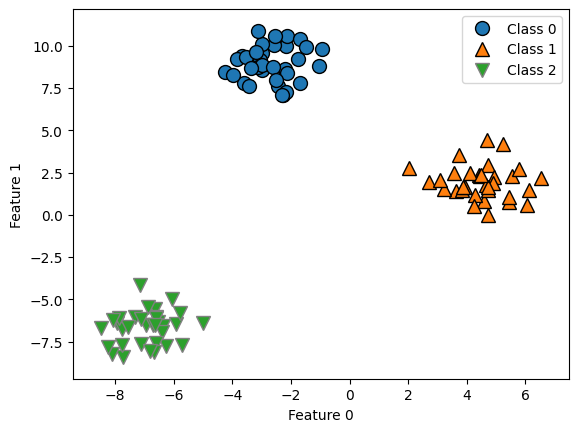

In [3]:
X, y = make_blobs(random_state=42)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(["Class 0", "Class 1", "Class 2"])

Many linear classification models are for binary classification only, and don’t extend naturally to the multiclass classification(except Logistic Regression)

Ex: LinearSVC

To handle this a common technique is used  to extend a binary classification algorithm to a multiclass classification algorithm known as "One-vs-rest" approach.


In the one-vs.-rest approach, a binary model is learned for each class that tries to separate that class from all of the other classes, resulting in as many binary models as there are classes. To make a prediction, all binary classifiers are run on a test point. The classifier that has the highest score(Confidence Score, which is calculated using linear decision function) on its single class “wins,” and this class label is returned as the prediction.

Each binary classifier learn it's own set of parameters.
* a coefficient vector
* an intercept

Below example trains a LinearSVC classifier on the above same dataset

In [4]:
# LinearSVC Model
linear_svm = LinearSVC()
linear_svm.fit(X, y)

LinearSVC()

In [5]:
print("Coefficient shape: ", linear_svm.coef_)
print("Intercept shape: ", linear_svm.intercept_)

Coefficient shape:  [[-0.17492412  0.23140766]
 [ 0.47622012 -0.06936786]
 [-0.18914207 -0.20400079]]
Intercept shape:  [-1.07745775  0.13139239 -0.08604962]


We see that the shape of the coef_ is (3, 2), meaning that each row of coef_ contains the coefficient vector for one of the three classes and each column holds the coefficient value for a specific feature (there are two in this dataset). The intercept_ is now a one-dimensional array, storing the intercepts for each class.

Below illustration visualizes the decision boundaries found by each binary classifier

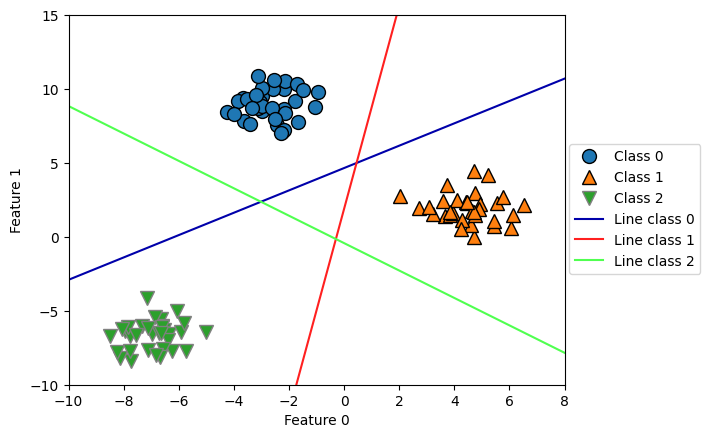

In [6]:
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
line = np.linspace(-15, 15)
for coef, intercept, color in zip(linear_svm.coef_, linear_svm.intercept_,
                                  mglearn.cm3.colors):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1], c=color)
plt.ylim(-10, 15)
plt.xlim(-10, 8)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(['Class 0', 'Class 1', 'Class 2', 'Line class 0', 'Line class 1',
            'Line class 2'], loc=(1.01, 0.3))

We can see that all the points belonging to class 0 in the training data are above the line corresponding to class 0, which means they are on the “class 0” side of this binary classifier. The points in class 0 are above the line corresponding to class 2, which means they are classified as “rest” by the binary classifier for class 2. The points belonging to class 0 are to the left of the line corresponding to class 1, which means the binary classifier for class 1 also classifies them as “rest.” Therefore, any point in this area will be classified as class 0 by the final classifier (the result of the classification confidence formula for classifier 0 is greater than zero, while it is smaller than zero for the other two classes).

In the central triangle, All three binary classifiers classify points there as “rest”. A point in there is assigned to a class with highest score, which corresponds to the closest decision boundry.

Below illustration shows the predictions for all regions of the 2D space

Text(0, 0.5, 'Feature 1')

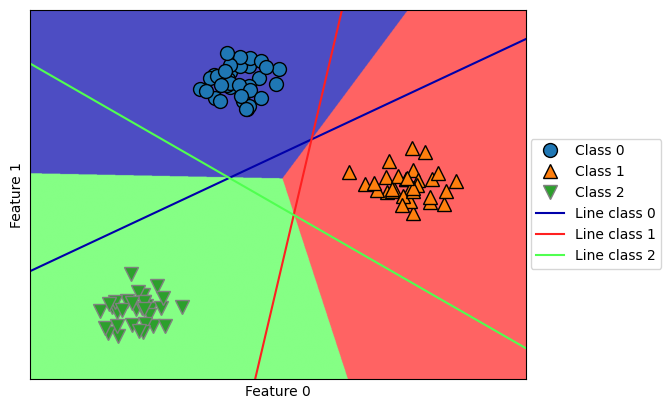

In [7]:
mglearn.plots.plot_2d_classification(linear_svm, X, fill=True, alpha=.7)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
line = np.linspace(-15, 15)
for coef, intercept, color in zip(linear_svm.coef_, linear_svm.intercept_,
                                  mglearn.cm3.colors):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1], c=color)
plt.legend(['Class 0', 'Class 1', 'Class 2', 'Line class 0', 'Line class 1',
            'Line class 2'], loc=(1.01, 0.3))
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")